# Customer Segmentation & Churn Pattern Analytics in European Banking

## Notebook 03: Churn Distribution & Comparative Demographic Analysis

---

### Project Overview

Understanding customer churn requires more than measuring the overall churn rate. It is essential to identify which customer segments experience higher levels of churn, compare the characteristics of churned and retained customers, and examine how demographic and financial factors influence customer attrition.

This notebook analyzes churn distribution across multiple customer segments and investigates demographic and financial patterns associated with churn. The findings will help identify high-risk customer groups and support data-driven customer retention strategies.

---

## Objectives

The objectives of this notebook are to:

A. Analyze the overall distribution of customer churn.

B. Compare churn rates across different customer segments.

C. Evaluate the contribution of each segment to total churn.

D. Compare the characteristics of churned and retained customers.

E. Investigate demographic and financial factors associated with customer churn.

---

## Expected Outcome

By the end of this notebook, the key customer segments contributing to churn will be identified, along with the demographic and financial characteristics most strongly associated with customer attrition. These insights will provide the foundation for the final business recommendations and risk analysis.

---

## A. Load the Cleaned Dataset

The cleaned dataset generated in the previous notebook is loaded for exploratory analysis. This dataset already contains the required transformations and derived segmentation fields, allowing the analysis to focus entirely on discovering business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/Processed/European_bank_cleaned.csv")

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreBand,BalanceCategory,TenureGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30–45,Fair,Zero Balance,New Customer
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30–45,Fair,Medium Balance,New Customer
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30–45,Poor,High Balance,Established Customer
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30–45,Good,Zero Balance,New Customer
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30–45,Excellent,High Balance,New Customer


---

## B. Overall Churn Distribution Analysis

The analysis begins by examining the overall distribution of retained and churned customers. This provides a baseline understanding of customer attrition before exploring how churn varies across different customer segments.

In [2]:
# To ignore the warnings and setting a style for our plotting 

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

In [3]:
churn_distribution = (
    df["Exited"]
    .value_counts()
    .rename_axis("Customer Status")
    .reset_index(name="Customer Count")
)

churn_distribution["Customer Status"] = (
    churn_distribution["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

churn_distribution["Percentage (%)"] = (
    churn_distribution["Customer Count"]
    / len(df)
    * 100
).round(2)

churn_distribution

,Customer Status,Customer Count,Percentage (%)
0,Retained,7963,79.63
1,Churned,2037,20.37


### Visualizing Overall Customer Churn

The following visualization illustrates the proportion of retained and churned customers, providing a clear overview of the bank's overall customer retention performance.

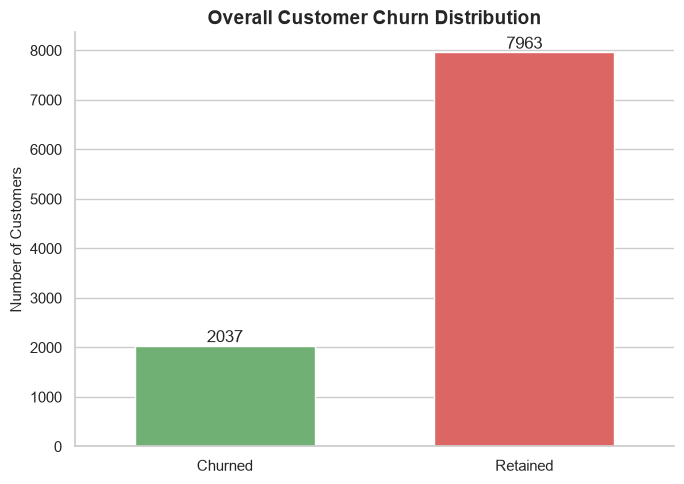

In [4]:
plot_data = df.copy()

plot_data["Customer Status"] = plot_data["Exited"].map({
    0: "Retained",
    1: "Churned"
})

ax = sns.countplot(
    data=plot_data,
    x="Customer Status",
    palette=["#66BB6A", "#EF5350"],
    width=0.6
)

plt.title("Overall Customer Churn Distribution")
plt.xlabel("")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.tight_layout()
plt.show()

---

## C. Segment-wise Churn Analysis

While the overall churn rate provides a general understanding of customer attrition, it does not reveal which customer groups are more likely to leave the bank.

This section examines churn rates across different customer segments, including geography, age group, credit score band, tenure group, and balance category. Comparing churn across these segments helps identify customer groups with relatively higher churn and supports more targeted retention strategies.

### 1. Geography-wise Churn Analysis

Customer churn may vary across different geographic regions due to differences in customer behaviour, market conditions, and banking preferences. Analyzing churn by geography helps identify regions with higher customer attrition and highlights areas where retention efforts may be most beneficial.

In [5]:
geography_churn = (
    df.groupby("Geography", observed=True)["Exited"]
      .agg(
          Total_Customers="count",
          Churned_Customers="sum",
          Churn_Rate=lambda x: round(x.mean() * 100, 2)
      )
      .sort_values("Churn_Rate", ascending=False)
)

geography_churn

,Total_Customers,Churned_Customers,Churn_Rate
Geography,,,
Germany,2509,814,32.44
Spain,2477,413,16.67
France,5014,810,16.15


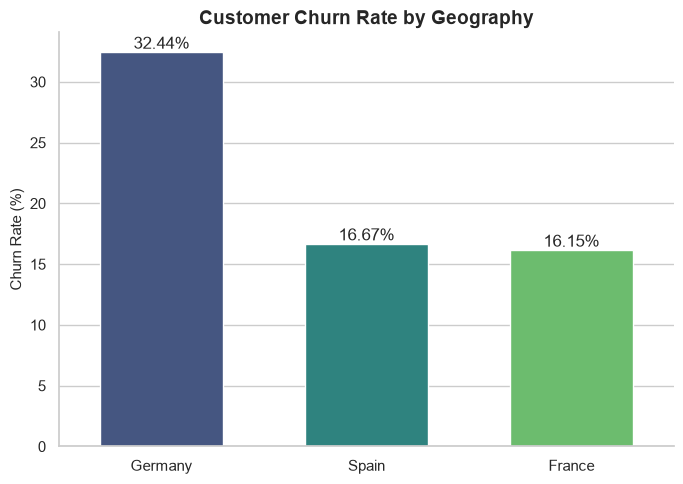

In [6]:
ax = sns.barplot(
    data=geography_churn.reset_index(),
    x="Geography",
    y="Churn_Rate",
    palette="viridis",
    width=0.6
)

plt.title("Customer Churn Rate by Geography")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- **Germany** has the highest churn rate at **32.44%**, with **814 out of 2,509 customers** leaving the bank.
- **Spain** and **France** have similar churn rates of **16.67%** and **16.15%**, respectively.
- Although **France** has the largest customer base (**5,014 customers**), it maintains one of the lowest churn rates.
- Customers in **Germany** are significantly more likely to churn compared to customers in France and Spain.

### **Business Insight**

- Germany is the highest-risk geographic segment for customer churn.
- Customer retention strategies should prioritize the German market.
- Further analysis is required to identify the factors contributing to Germany's higher churn rate.

### 2. Age Group-wise Churn Analysis

Customer age often influences banking behaviour, financial needs, and loyalty. Analyzing churn across different age groups helps identify which age segments are more likely to leave the bank and supports the development of targeted customer retention strategies.

In [7]:
agegroup_churn = (
    df.groupby("AgeGroup", observed=True)["Exited"]
    .agg(
        Total_Customers="count",
        Churned_Customers="sum",
        Churn_Rate=lambda x: round(x.mean() * 100, 2)
    )
    .sort_values("Churn_Rate", ascending=False)
)

agegroup_churn

,Total_Customers,Churned_Customers,Churn_Rate
AgeGroup,,,
46–60,1647,842,51.12
Above 60,464,115,24.78
30–45,5921,932,15.74
Below 30,1968,148,7.52


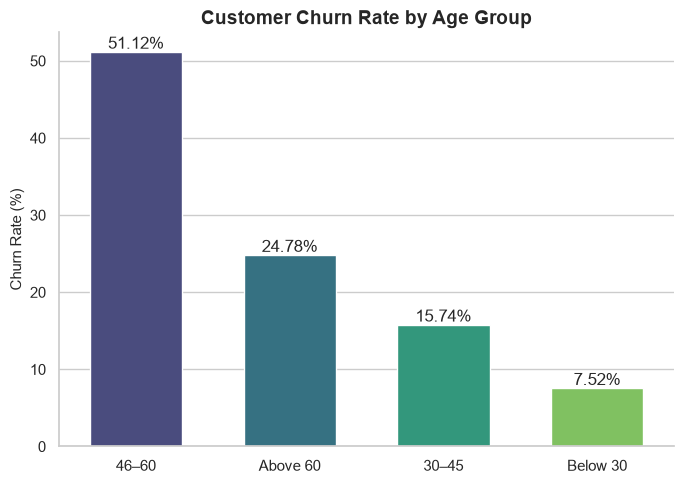

In [8]:
ax = sns.barplot(
    data=agegroup_churn.reset_index(),
    x="AgeGroup",
    y="Churn_Rate",
    palette="viridis",
    width=0.6
)

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Customers aged **46–60** have the highest churn rate at **51.12%**, with **842 out of 1,647 customers** leaving the bank.
- Customers **Above 60** have the second-highest churn rate at **24.78%**.
- The **30–45** age group has a relatively low churn rate of **15.74%**, despite being the largest customer segment.
- Customers **Below 30** are the least likely to churn, with a churn rate of only **7.52%**.
- Overall, customer churn increases noticeably with age, particularly for customers between **46 and 60 years**.

### Business Insight

- Customers aged **46–60** should be prioritized for customer retention initiatives.
- Age appears to be a significant factor influencing customer churn and should be considered when developing retention strategies.
- Personalized products and engagement programs for middle-aged and older customers may help reduce churn.

### 3. Credit Score Band-wise Churn Analysis

Credit score reflects a customer's financial reliability and may influence banking behaviour. Analyzing churn across different credit score bands helps determine whether customers with varying credit profiles exhibit different churn patterns.

In [9]:
creditscore_churn = (
    df.groupby("CreditScoreBand", observed=True)["Exited"]
    .agg(
        Total_Customers="count",
        Churned_Customers="sum",
        Churn_Rate=lambda x: round(x.mean() * 100, 2)
    )
    .sort_values("Churn_Rate", ascending=False)
)

creditscore_churn

,Total_Customers,Churned_Customers,Churn_Rate
CreditScoreBand,,,
Poor,2393,530,22.15
Fair,3350,683,20.39
Excellent,1860,373,20.05
Good,2397,451,18.82


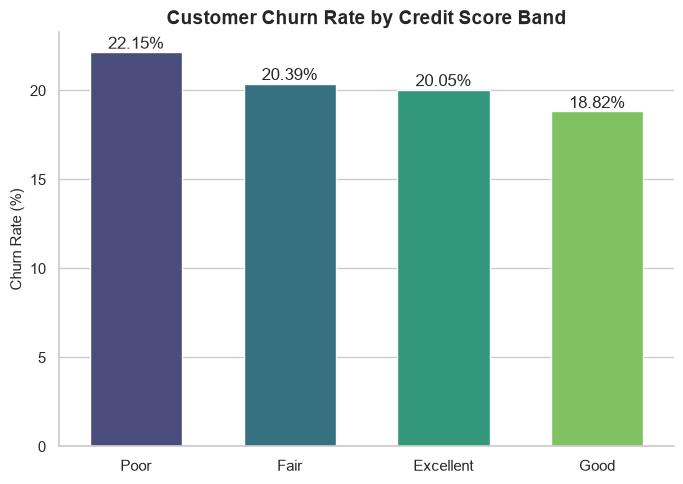

In [10]:
ax = sns.barplot(
    data=creditscore_churn.reset_index(),
    x="CreditScoreBand",
    y="Churn_Rate",
    palette="viridis",
    width=0.6
)

plt.title("Customer Churn Rate by Credit Score Band")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Customers with **Poor** credit scores have the highest churn rate at **22.15%**.
- The **Good** credit score band records the lowest churn rate at **18.82%**.
- **Fair** and **Excellent** credit score bands have similar churn rates of **20.39%** and **20.05%**, respectively.
- The variation in churn rates across credit score bands is relatively small, ranging from **18.82%** to **22.15%**.
- Overall, credit score shows only a moderate relationship with customer churn.

### Business Insight

- Credit score alone does not appear to be a strong predictor of customer churn.
- Customer retention strategies should consider additional factors such as age, geography, and account activity alongside credit score.
- Combining multiple customer attributes may provide more accurate identification of high-risk customers.

### 4. Tenure Group-wise Churn Analysis

Customer tenure reflects the length of a customer's relationship with the bank. Analyzing churn across different tenure groups helps determine whether customer loyalty and relationship duration influence the likelihood of churn.

In [11]:
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["Exited"]
    .agg(
        Total_Customers="count",
        Churned_Customers="sum",
        Churn_Rate=lambda x: round(x.mean() * 100, 2)
    )
    .sort_values("Churn_Rate", ascending=False)
)

tenure_churn

,Total_Customers,Churned_Customers,Churn_Rate
TenureGroup,,,
Loyal Customer,1474,314,21.30
New Customer,2496,528,21.15
Developing Customer,3010,625,20.76
Established Customer,3020,570,18.87


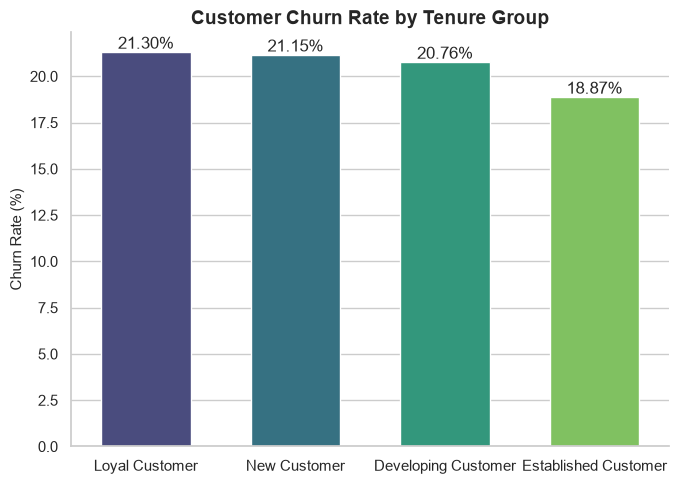

In [12]:
ax = sns.barplot(
    data=tenure_churn.reset_index(),
    x="TenureGroup",
    y="Churn_Rate",
    palette="viridis",
    width=0.6
)

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- **Loyal Customers** have the highest churn rate at **21.30%**.
- **Established Customers** record the lowest churn rate at **18.87%**.
- **New Customers** and **Developing Customers** have similar churn rates of **21.15%** and **20.76%**, respectively.
- The difference between the highest and lowest churn rates is only **2.43 percentage points**.
- Overall, churn rates remain relatively consistent across all tenure groups.

### Business Insight

- Customer tenure alone does not appear to be a strong indicator of churn.
- Both new and long-term customers exhibit comparable churn rates, suggesting that retention efforts should target customers across all stages of their relationship with the bank.
- Combining tenure with other customer attributes may provide more meaningful insights into churn behaviour.

### 5. Balance Category-wise Churn Analysis

Account balance reflects a customer's financial engagement with the bank. Analyzing churn across different balance categories helps identify whether customers with varying account balances exhibit different churn patterns.

In [13]:
balance_churn = (
    df.groupby("BalanceCategory", observed=True)["Exited"]
    .agg(
        Total_Customers="count",
        Churned_Customers="sum",
        Churn_Rate=lambda x: round(x.mean() * 100, 2)
    )
    .sort_values("Churn_Rate", ascending=False)
)

balance_churn

,Total_Customers,Churned_Customers,Churn_Rate
BalanceCategory,,,
Low Balance,75,26,34.67
High Balance,4799,1211,25.23
Medium Balance,1509,300,19.88
Zero Balance,3617,500,13.82


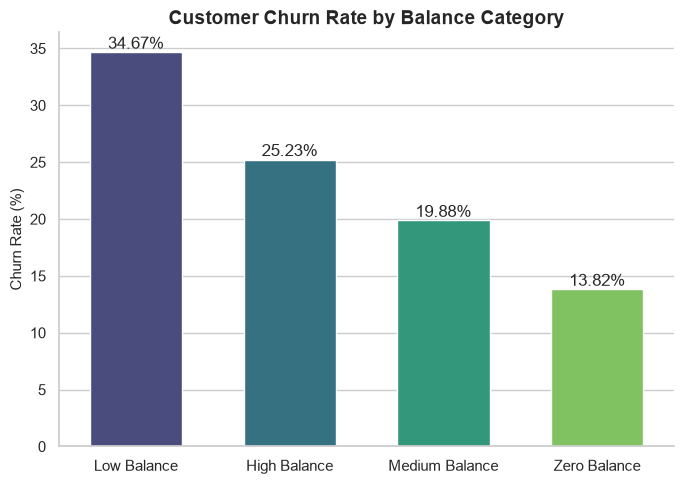

In [14]:
ax = sns.barplot(
    data=balance_churn.reset_index(),
    x="BalanceCategory",
    y="Churn_Rate",
    palette="viridis",
    width=0.6
)

plt.title("Customer Churn Rate by Balance Category")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Customers with **High Balance** accounts have the highest churn rate at **25.23%**.
- Customers with **Medium Balance** accounts have a churn rate of **19.88%**.
- Customers with **Zero Balance** accounts record the lowest churn rate at **13.82%**.
- The difference between the highest and lowest churn rates is **11.41 percentage points**, indicating a noticeable relationship between account balance and customer churn.
- Overall, customers with higher account balances appear more likely to churn than those with lower or zero balances.

### Business Insight

- Customers with high account balances should be prioritized for retention, as they represent both a higher churn risk and potentially greater business value.
- Personalized financial products, loyalty benefits, and proactive engagement may help reduce churn among high-balance customers.
- Account balance should be considered alongside age and geography when identifying customers at risk of churning.

---
## D. Churn Contribution by Segment Size

While churn rate indicates the likelihood of customers leaving within a segment, it does not reflect the overall volume of churn. This section analyzes the number of churned customers contributed by different customer segments to identify where the bank experiences the greatest customer loss.

### 1. Geography-wise Churn Contribution

This analysis shows the total number of customers who churned from each geographical region, helping identify which market contributes the largest share of customer losses.

In [15]:
geography_contribution = (
    df[df["Exited"] == 1]
    .groupby("Geography", observed=True)
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Churned_Customers")
)

geography_contribution

,Geography,Churned_Customers
0,Germany,814
1,France,810
2,Spain,413


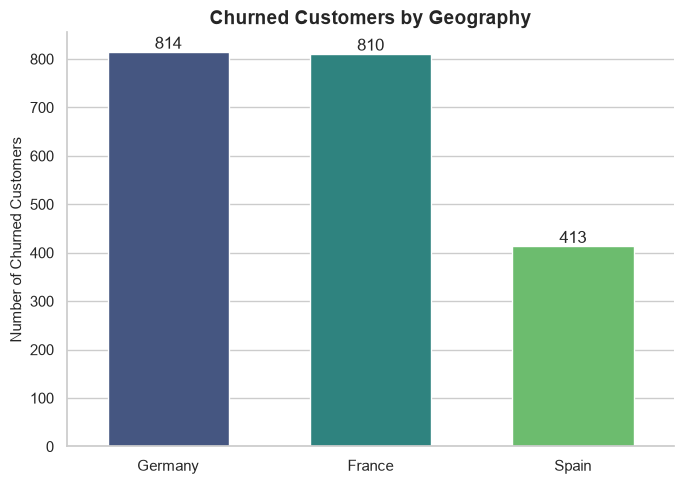

In [16]:
ax = sns.barplot(
    data=geography_contribution,
    x="Geography",
    y="Churned_Customers",
    palette="viridis",
    width=0.6
)

plt.title("Churned Customers by Geography")
plt.xlabel("")
plt.ylabel("Number of Churned Customers")

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- **Germany** contributes the highest number of churned customers with **814** customers.
- **France** follows closely with **810** churned customers despite having a much lower churn rate.
- **Spain** contributes the fewest churned customers (**413**).
- Although France has a lower churn rate than Germany, its larger customer base results in a similar number of churned customers.
- Germany and France together account for the majority of customer churn in the dataset.

### Business Insight

- Customer retention efforts should primarily focus on **Germany** due to its high churn rate and large number of churned customers.
- **France** should also be prioritized, as reducing churn in its large customer base could significantly decrease overall customer losses.
- Combining churn rate with churn volume provides a more comprehensive view for prioritizing retention strategies.

### 2. Age Group-wise Churn Contribution

This analysis identifies which age groups contribute the highest number of churned customers, helping determine where the largest customer losses occur.

In [17]:
age_contribution = (
    df[df["Exited"] == 1]
    .groupby("AgeGroup", observed=True)
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Churned_Customers")
)

age_contribution

,AgeGroup,Churned_Customers
0,30–45,932
1,46–60,842
2,Below 30,148
3,Above 60,115


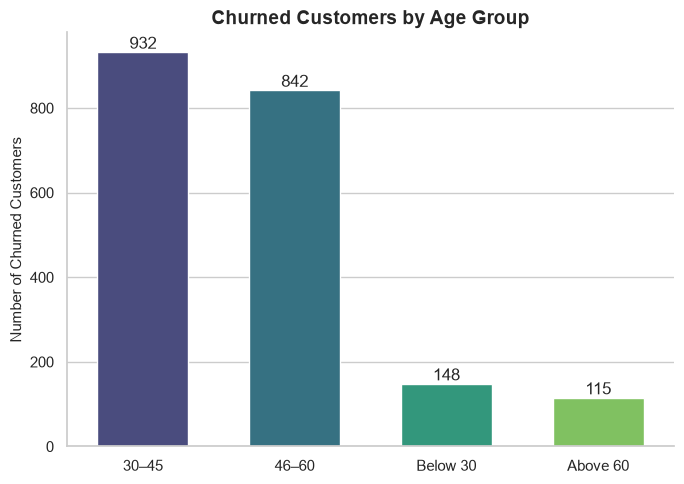

In [18]:
ax = sns.barplot(
    data=age_contribution,
    x="AgeGroup",
    y="Churned_Customers",
    palette="viridis",
    width=0.6
)

plt.title("Churned Customers by Age Group")
plt.xlabel("")
plt.ylabel("Number of Churned Customers")

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Customers aged **30–45** contribute the highest number of churned customers (**932**).
- The **46–60** age group records the second-highest churn contribution with **842** churned customers.
- Customers **Below 30** and **Above 60** contribute relatively few churned customers, with **148** and **115** churned customers, respectively.
- Although the **46–60** age group has the highest churn rate, the **30–45** age group contributes the largest number of churned customers due to its larger customer base.
- Together, the **30–45** and **46–60** age groups account for the majority of customer churn in the dataset.

### Business Insight

- Retention strategies should prioritize both the **30–45** and **46–60** age groups, as they contribute the largest number of churned customers.
- The **30–45** age group offers the greatest opportunity to reduce overall churn because of its large customer base.
- Combining churn rate and churn contribution helps identify customer segments that are both high-risk and high-impact.

### 3. Credit Score Band-wise Churn Contribution

This analysis examines the total number of churned customers across different credit score bands to identify which customer groups contribute the most to overall customer losses.

In [19]:
creditscore_contribution = (
    df[df["Exited"] == 1]
    .groupby("CreditScoreBand", observed=True)
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Churned_Customers")
)

creditscore_contribution

,CreditScoreBand,Churned_Customers
0,Fair,683
1,Poor,530
2,Good,451
3,Excellent,373


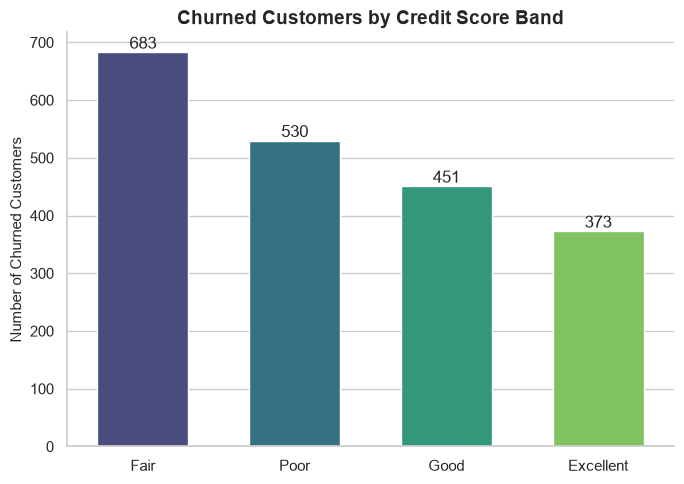

In [20]:
ax = sns.barplot(
    data=creditscore_contribution,
    x="CreditScoreBand",
    y="Churned_Customers",
    palette="viridis",
    width=0.6
)

plt.title("Churned Customers by Credit Score Band")
plt.xlabel("")
plt.ylabel("Number of Churned Customers")

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Customers with **Fair** credit scores contribute the highest number of churned customers (**683**).
- The **Poor** credit score band records the second-highest churn contribution with **530** churned customers.
- Customers with **Good** and **Excellent** credit scores contribute **451** and **373** churned customers, respectively.
- Although the **Poor** credit score band has the highest churn rate, the **Fair** credit score band contributes more churned customers due to its larger customer base.
- Overall, customer churn is distributed across all credit score bands without a single dominant segment.

### Business Insight

- Customers with **Fair** credit scores should be included in retention strategies because they contribute the largest number of churned customers.
- Credit score alone is insufficient for identifying high-risk customers, as churn is spread across multiple credit score bands.
- Combining credit score with other factors such as age, geography, and account balance can improve churn prediction and customer retention efforts.

### 4. Tenure Group-wise Churn Contribution

This analysis evaluates the total number of churned customers across different tenure groups to determine which stages of the customer lifecycle contribute the most to overall customer churn.

In [21]:
tenure_contribution = (
    df[df["Exited"] == 1]
    .groupby("TenureGroup", observed=True)
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Churned_Customers")
)

tenure_contribution

,TenureGroup,Churned_Customers
0,Developing Customer,625
1,Established Customer,570
2,New Customer,528
3,Loyal Customer,314


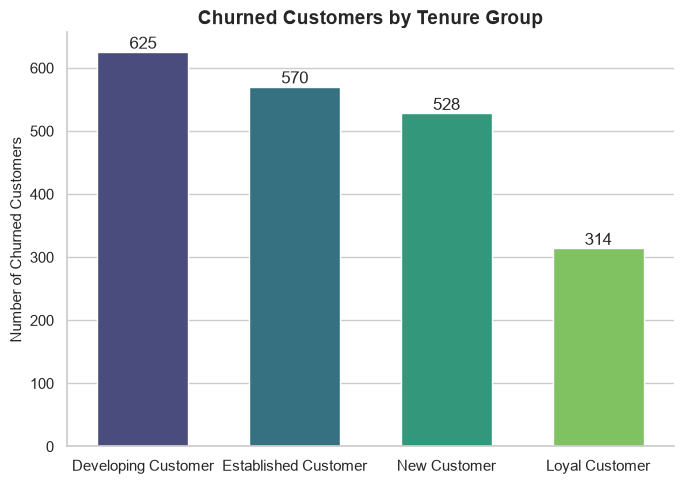

In [22]:
ax = sns.barplot(
    data=tenure_contribution,
    x="TenureGroup",
    y="Churned_Customers",
    palette="viridis",
    width=0.6
)

plt.title("Churned Customers by Tenure Group")
plt.xlabel("")
plt.ylabel("Number of Churned Customers")

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- **Developing Customers** contribute the highest number of churned customers (**625**).
- **Established Customers** record the second-highest churn contribution with **570** churned customers.
- **New Customers** contribute **528** churned customers, while **Loyal Customers** contribute the fewest (**314**).
- Although **Loyal Customers** have the highest churn rate, they contribute the lowest number of churned customers due to their smaller customer base.
- Customer churn is distributed across all tenure groups, with no single stage dominating overall churn.

### Business Insight

- Retention strategies should give priority to **Developing** and **Established Customers**, as they contribute the largest number of churned customers.
- Customer tenure alone is not sufficient to identify high-risk customers, since churn is distributed across all tenure groups.
- Combining tenure with other customer attributes, such as age, geography, and account balance, can provide more effective customer retention strategies.

### 5. Balance Category-wise Churn Contribution

This analysis examines the total number of churned customers across different account balance categories to identify which customer groups contribute the most to overall customer losses.

In [23]:
balance_contribution = (
    df[df["Exited"] == 1]
    .groupby("BalanceCategory", observed=True)
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Churned_Customers")
)

balance_contribution

,BalanceCategory,Churned_Customers
0,High Balance,1211
1,Zero Balance,500
2,Medium Balance,300
3,Low Balance,26


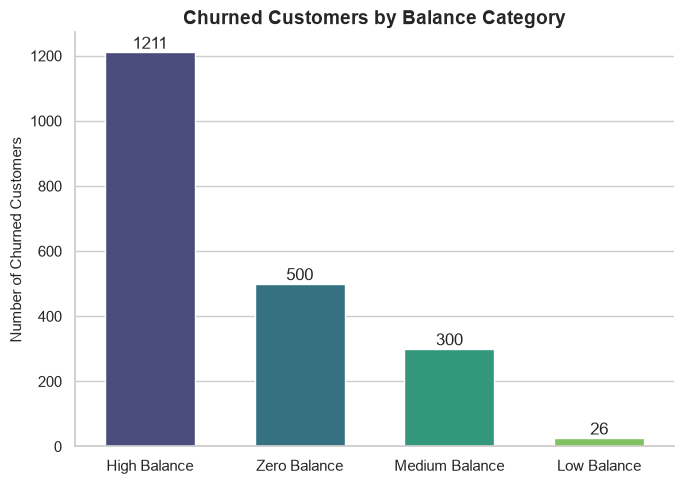

In [24]:
ax = sns.barplot(
    data=balance_contribution,
    x="BalanceCategory",
    y="Churned_Customers",
    palette="viridis",
    width=0.6
)

plt.title("Churned Customers by Balance Category")
plt.xlabel("")
plt.ylabel("Number of Churned Customers")

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Customers with **High Balance** accounts contribute the highest number of churned customers (**1,211**).
- **Zero Balance** customers record the second-highest churn contribution with **500** churned customers.
- **Medium Balance** customers contribute **300** churned customers.
- **Low Balance** customers contribute the fewest churned customers (**26**).
- The majority of customer churn originates from **High Balance** customers, indicating a significant concentration of customer losses within this segment.

### Business Insight

- **High Balance** customers should be the highest priority for retention initiatives, as they contribute the largest share of customer churn.
- Reducing churn among high-balance customers could have the greatest impact on preserving customer value and improving overall retention.
- Targeted retention strategies based on account balance, combined with age and geography, can help the bank focus on its most valuable at-risk customers.

---
## E. Churned vs Retained Customer Profiles

This section compares the characteristics of churned and retained customers to identify key differences in their demographic and financial profiles. By analyzing numerical features, we can better understand the factors associated with customer churn.

## 1. Churned vs Retained Customer Profiles

This section compares the characteristics of churned and retained customers to identify key differences in their demographic and financial profiles. By analyzing numerical features, we can better understand the factors associated with customer churn.

In [25]:
profile_comparison = (
    df.groupby("Exited")
    .agg({
        "Age": "mean",
        "CreditScore": "mean",
        "Balance": "mean",
        "EstimatedSalary": "mean",
        "Tenure": "mean",
        "NumOfProducts": "mean"
    })
    .round(2)
)

profile_comparison.index = ["Retained", "Churned"]

profile_comparison

,Age,CreditScore,Balance,EstimatedSalary,Tenure,NumOfProducts
Retained,37.41,651.85,72745.30,99738.39,5.03,1.54
Churned,44.84,645.35,91108.54,101465.68,4.93,1.48


### Observation

- Churned customers are, on average, **older (44.84 years)** than retained customers (**37.41 years**).
- Churned customers maintain a **higher average account balance (91,108.54)** compared to retained customers (**72,745.30**).
- Retained customers have a slightly **higher average credit score (651.85)** than churned customers (**645.35**).
- The average **estimated salary** is similar for both groups, indicating that income alone has little influence on customer churn.
- The average **tenure** is nearly the same for both groups, suggesting that relationship duration has a limited impact on churn.
- Churned customers own **slightly fewer banking products (1.48)** than retained customers (**1.54**).

### Business Insight

- Older customers with higher account balances appear more likely to churn and should be prioritized in customer retention strategies.
- Credit score, salary, and tenure show only minor differences between churned and retained customers, indicating that these factors alone are not strong predictors of churn.
- Encouraging customers to adopt additional banking products may improve customer engagement and reduce the likelihood of churn.

### 2. Age Distribution by Customer Status

This visualization compares the age distribution of churned and retained customers to determine whether customer age is associated with churn.

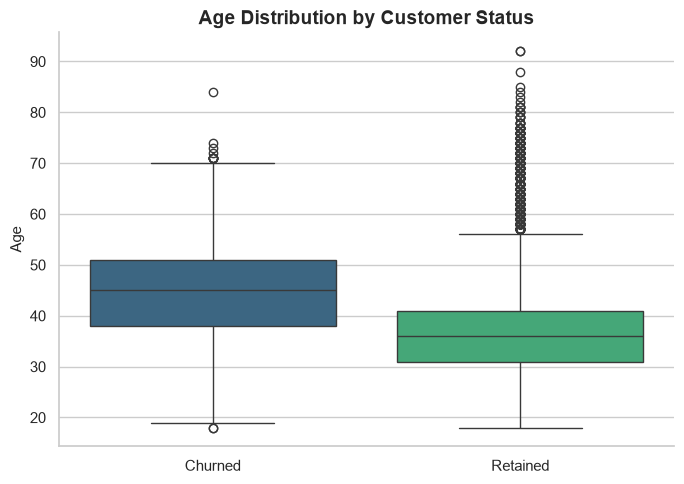

In [26]:
plot_data = df.copy()

plot_data["Customer Status"] = plot_data["Exited"].map({
    0: "Retained",
    1: "Churned"
})

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_data,
    x="Customer Status",
    y="Age",
    palette="viridis"
)

plt.title("Age Distribution by Customer Status")
plt.xlabel("")
plt.ylabel("Age")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- The median age of **churned customers** is noticeably higher than that of **retained customers**.
- The age distribution of churned customers is shifted toward older age groups, indicating that older customers are more likely to leave the bank.
- The retained customer group has a lower median age, with most customers concentrated between approximately **30 and 40 years**.
- Both groups contain several age outliers, with retained customers showing a larger number of older outliers.
- Overall, the box plot reinforces that **customer age is strongly associated with churn**, consistent with the earlier age group analysis.

### Business Insight

- Older customers should be prioritized for customer retention initiatives, as they exhibit a higher likelihood of churning.
- Age can serve as an important feature for customer segmentation and churn prediction models.
- Personalized products and engagement strategies tailored to older customers may help improve customer retention.

### 3. Balance Distribution by Customer Status

This visualization compares the account balance distribution of churned and retained customers to determine whether account balance is associated with customer churn.

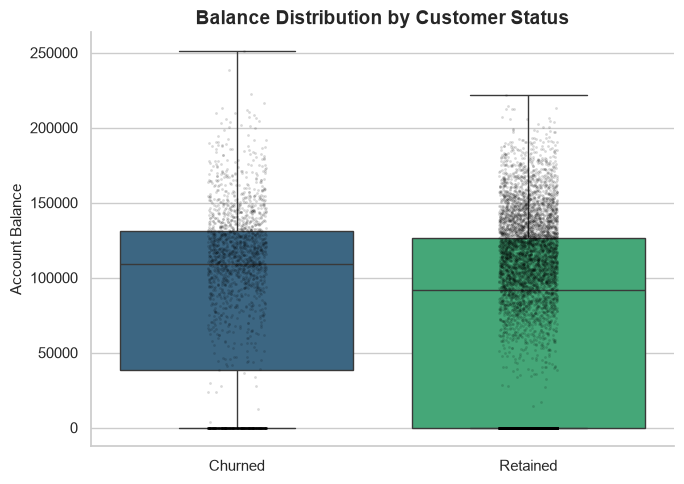

In [27]:
plot_data = df.copy()

plot_data["Customer Status"] = plot_data["Exited"].map({
    0: "Retained",
    1: "Churned"
})

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_data,
    x="Customer Status",
    y="Balance",
    palette="viridis"
)
sns.stripplot(
    data=plot_data,
    x="Customer Status",
    y="Balance",
    color="black",
    alpha=0.15,
    size=2
)

plt.title("Balance Distribution by Customer Status")
plt.xlabel("")
plt.ylabel("Account Balance")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Churned customers have a **higher median account balance** than retained customers.
- A large proportion of retained customers have **zero or very low account balances**, whereas churned customers are more concentrated in the higher balance range.
- The strip plot shows a higher density of churned customers with balances between approximately **£100,000 and £150,000**.
- Both customer groups exhibit a wide range of account balances, indicating considerable variation in customer financial profiles.
- The visualization reinforces that customers with higher account balances are more likely to churn.

### Business Insight

- High-balance customers should be the primary focus of customer retention initiatives, as they are both more likely to churn and represent greater business value.
- Relationship management programs and personalized financial services can help improve retention among high-value customers.
- Account balance should be incorporated as an important feature in customer segmentation and churn prediction models.

### 4. Credit Score Distribution by Customer Status

This visualization compares the credit score distribution of churned and retained customers to determine whether creditworthiness differs between the two groups.

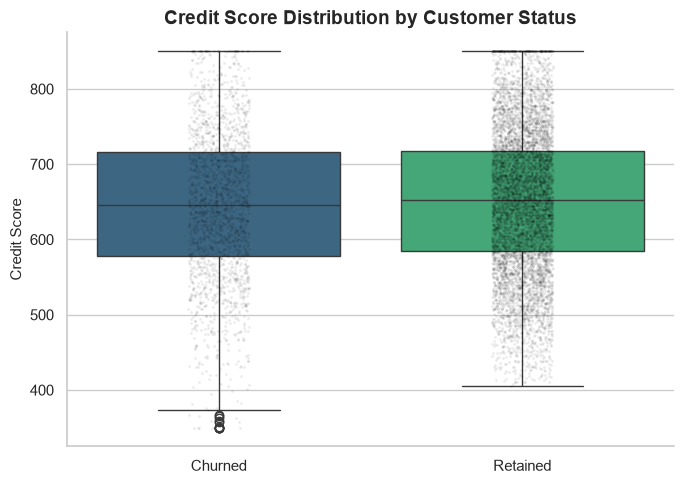

In [28]:
plot_data = df.copy()

plot_data["Customer Status"] = plot_data["Exited"].map({
    0: "Retained",
    1: "Churned"
})

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_data,
    x="Customer Status",
    y="CreditScore",
    palette="viridis"
)

sns.stripplot(
    data=plot_data,
    x="Customer Status",
    y="CreditScore",
    color="black",
    alpha=0.08,
    size=2
)

plt.title("Credit Score Distribution by Customer Status")
plt.xlabel("")
plt.ylabel("Credit Score")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- The credit score distributions of churned and retained customers are highly similar.
- Retained customers have a slightly higher median credit score than churned customers.
- The interquartile ranges (IQRs) of both groups largely overlap, indicating similar variability in credit scores.
- Both customer groups contain customers with both low and high credit scores, showing a wide distribution.
- Overall, credit score alone does not appear to have a strong influence on customer churn.

### Business Insight

- Credit score alone is not a reliable indicator of customer churn and should not be used as the sole basis for retention strategies.
- More effective churn prediction can be achieved by combining credit score with other factors such as age, account balance, and geography.
- Customer retention initiatives should focus on multiple customer attributes rather than relying solely on financial creditworthiness.

---
## F. Comparative Demographic Analysis

This section explores how demographic and financial characteristics influence customer churn. By comparing customer groups across multiple dimensions, we can identify patterns that support more effective customer segmentation and retention strategies.

### 1. Gender-based Churn Analysis

This analysis compares customer churn across gender to determine whether male and female customers exhibit different churn behaviours.

In [29]:
gender_churn = (
    df.groupby("Gender", observed=True)["Exited"]
    .agg(
        Total_Customers="count",
        Churned_Customers="sum",
        Churn_Rate=lambda x: round(x.mean() * 100, 2)
    )
)

gender_churn

,Total_Customers,Churned_Customers,Churn_Rate
Gender,,,
Female,4543,1139,25.07
Male,5457,898,16.46


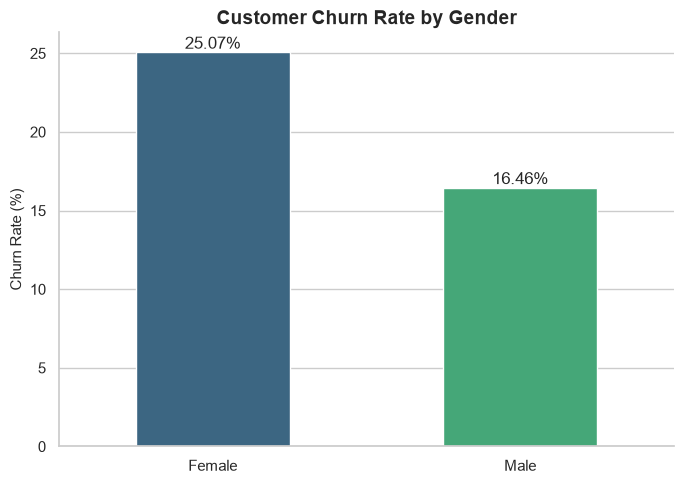

In [30]:
ax = sns.barplot(
    data=gender_churn.reset_index(),
    x="Gender",
    y="Churn_Rate",
    palette="viridis",
    width=0.5
)

plt.title("Customer Churn Rate by Gender")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- The dataset contains **5,457 male customers** and **4,543 female customers**.
- Female customers have a churn rate of **25.07%**, while male customers have a churn rate of **16.46%**.
- The difference of **8.61 percentage points** indicates that female customers are significantly more likely to leave the bank than male customers.
- This suggests that gender may be an important demographic factor associated with customer churn in this dataset.

### 2. Geography × Age Analysis

This analysis examines how customer churn varies across different age groups within each geographical region. By combining these two factors, we can identify customer segments that exhibit the highest churn risk.

In [31]:
geo_age_churn = (
    df.pivot_table(
        values="Exited",
        index="Geography",
        columns="AgeGroup",
        aggfunc="mean",
        observed=True
    ) * 100
).round(2)

geo_age_churn

AgeGroup,30–45,46–60,Above 60,Below 30
Geography,,,,
France,12.35,45.79,19.91,4.91
Germany,26.09,67.33,38.94,12.36
Spain,12.53,40.66,20.83,8.60


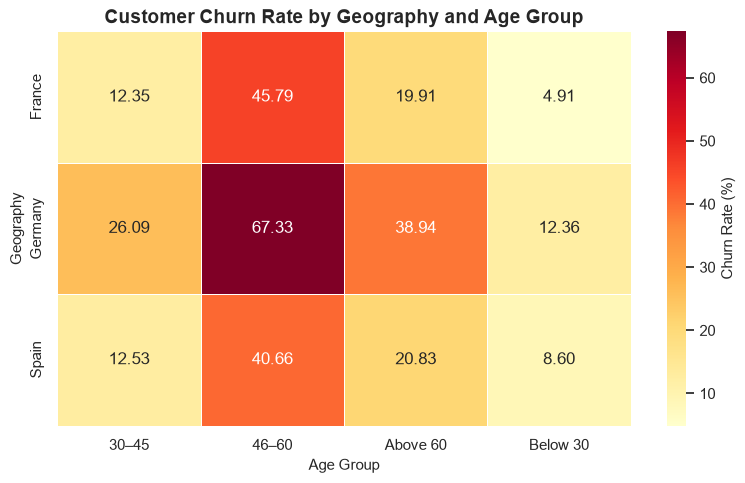

In [32]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    geo_age_churn,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title("Customer Churn Rate by Geography and Age Group")
plt.xlabel("Age Group")
plt.ylabel("Geography")

plt.tight_layout()
plt.show()

### Observation

- Customers aged **46–60 years** exhibit the highest churn rate across all three geographical regions.
- **Germany** consistently records the highest churn rate in every age group, with the **46–60** segment reaching **67.33%**, the highest churn observed in the analysis.
- **France** and **Spain** show similar churn patterns, with comparatively lower churn rates across all age groups.
- Customers **below 30 years** have the lowest churn rates in every region, indicating stronger customer retention among younger customers.
- The combined analysis suggests that both **geography** and **age** jointly influence customer churn, with older customers in Germany representing the highest-risk customer segment.

### Business Insight

The bank should prioritize retention efforts for **customers aged 46–60 in Germany**, as this segment demonstrates the highest likelihood of churn. Region-specific retention strategies, personalized financial products, and proactive customer engagement for high-risk age groups can help reduce customer attrition more effectively than applying a uniform retention strategy across all customers.

### 3. Financial Stability vs Churn

This analysis investigates how customer churn varies across different combinations of credit score bands and account balance categories. Examining these financial characteristics together helps identify high-risk customer segments and supports more targeted retention strategies.

In [33]:
financial_churn = (
    df.pivot_table(
        values="Exited",
        index="CreditScoreBand",
        columns="BalanceCategory",
        aggfunc="mean",
        observed=True
    ) * 100
).round(2)

financial_churn

BalanceCategory,High Balance,Low Balance,Medium Balance,Zero Balance
CreditScoreBand,,,,
Excellent,25.08,27.27,18.40,13.51
Fair,25.09,36.36,18.81,14.36
Good,22.93,22.22,20.44,12.95
Poor,27.77,53.85,22.19,14.22


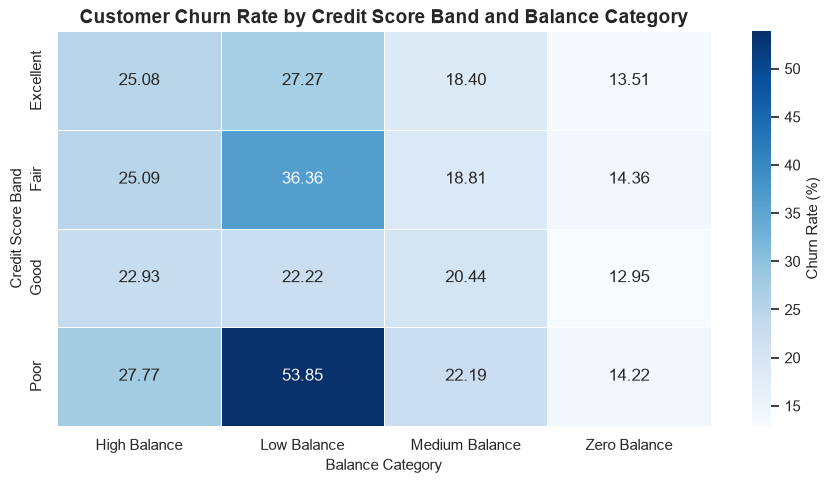

In [34]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    financial_churn,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title("Customer Churn Rate by Credit Score Band and Balance Category")
plt.xlabel("Balance Category")
plt.ylabel("Credit Score Band")

plt.tight_layout()
plt.show()

### Observation

- Customers with **high account balances** consistently exhibit higher churn rates across all credit score bands, ranging from **22.93% to 27.77%**.
- Among high-balance customers, those with **poor credit scores** have the highest churn rate (**27.77%**), indicating the greatest financial risk segment.
- Customers with **zero account balances** show the lowest churn rates across all credit score bands (approximately **13–14%**), suggesting stronger retention within this group.
- Although some low-balance categories display high churn rates, these groups contain very few customers and therefore have limited impact on the overall customer base.
- Overall, **account balance appears to have a stronger association with churn than credit score**, while customers combining high balances with poor credit scores represent the highest-risk financial segment.

### Business Insight

The bank should prioritize retention efforts for **high-balance customers**, particularly those with **poor or fair credit scores**, as they represent the greatest financial risk if lost. Personalized financial advisory services, loyalty benefits, and proactive customer engagement can help retain these high-value customers and reduce overall churn.

---
## G. High-Value Customer Churn Analysis

While the previous analyses identified customer segments with higher churn rates, this section focuses on the business impact of churn. High-value customers contribute significantly to the bank's deposits and profitability, making their loss more costly than the loss of lower-value customers.

---
## G. Summary of Findings

The exploratory data analysis identified several key factors associated with customer churn in the European banking dataset.

### Key Findings

- The overall customer churn rate is **20.37%**, with approximately one in five customers leaving the bank.
- **Germany** records the highest churn rate among all geographical regions, making it the primary market for customer retention initiatives.
- Customers aged **46–60 years** exhibit the highest churn rates across all age groups, indicating that churn increases with customer age.
- **Female customers** have a significantly higher churn rate (**25.07%**) than male customers (**16.46%**), suggesting gender is an important demographic factor in this dataset.
- Customers with **high account balances** are more likely to churn than those with lower or zero balances, highlighting the risk of losing high-value customers.
- The combination of **high balances and poor credit scores** represents the highest financial churn risk, while customers with zero balances consistently show the lowest churn rates.
- The **Geography × Age** analysis reveals that customers aged **46–60 in Germany** form the highest-risk customer segment, making them the most suitable target for focused retention strategies.
- Overall, **age, geography, gender, and account balance** demonstrate stronger relationships with customer churn than **credit score** or **customer tenure**.

### Conclusion

The analysis shows that customer churn is influenced by a combination of demographic and financial characteristics rather than a single factor. These insights provide a strong foundation for customer segmentation, targeted retention strategies, and the development of predictive machine learning models in future stages of the project.

In [37]:
high_value_churn = df[
    (df["Exited"] == 1) &
    (df["BalanceCategory"] == "High Balance")
]

summary = pd.DataFrame({
    "Metric": [
        "Total Churned Customers",
        "High-Balance Churners",
        "Average Balance",
        "Median Balance",
        "Maximum Balance"
    ],
    "Value": [
        df["Exited"].sum(),
        len(high_value_churn),
        round(high_value_churn["Balance"].mean(), 2),
        round(high_value_churn["Balance"].median(), 2),
        round(high_value_churn["Balance"].max(), 2)
    ]
})

summary

,Metric,Value
0,Total Churned Customers,2037.00
1,High-Balance Churners,1211.00
2,Average Balance,131700.82
3,Median Balance,127209.00
4,Maximum Balance,250898.09


### Observation

- Out of **2,037 customers** who churned, **1,211 (59.45%)** belonged to the **High Balance** segment.
- Churned high-value customers maintained an average account balance of **£131,700.82**, with a median balance of **£127,209.00**.
- The highest recorded balance among churned customers was **£250,898.09**, indicating that some of the bank's most valuable customers were lost.
- These findings suggest that customer churn is not limited to low-value accounts but also affects customers with substantial deposits.

### Business Insight

Nearly **three out of every five churned customers** were high-balance customers, highlighting a significant business risk. Retaining these customers should be a strategic priority, as losing high-value accounts can have a greater financial impact than losing a larger number of low-balance customers. Personalized relationship management, premium banking services, and proactive retention programs could help reduce the loss of these valuable customers.

### Revenue at Risk

Customer churn affects not only the number of customers retained by the bank but also the total value of deposits associated with those customers. This analysis quantifies the financial impact of churn by comparing the total account balances of churned and retained customers.

In [39]:
revenue_risk = pd.DataFrame({
    "Metric": [
        "Total Balance (Churned Customers)",
        "Total Balance (Retained Customers)",
        "Total Deposits",
        "Deposits Associated with Churn (%)",
        "Average Balance (Churned)",
        "Average Balance (Retained)"
    ],
    "Value": [
        round(df[df["Exited"] == 1]["Balance"].sum(), 2),
        round(df[df["Exited"] == 0]["Balance"].sum(), 2),
        round(df["Balance"].sum(), 2),
        round(
            df[df["Exited"] == 1]["Balance"].sum()
            / df["Balance"].sum() * 100,
            2
        ),
        round(df[df["Exited"] == 1]["Balance"].mean(), 2),
        round(df[df["Exited"] == 0]["Balance"].mean(), 2)
    ]
})

revenue_risk

,Metric,Value
0,Total Balance (Churned Customers),1.855881e+08
1,Total Balance (Retained Customers),5.792708e+08
2,Total Deposits,7.648589e+08
3,Deposits Associated with Churn (%),2.426000e+01
4,Average Balance (Churned),9.110854e+04
5,Average Balance (Retained),7.274530e+04


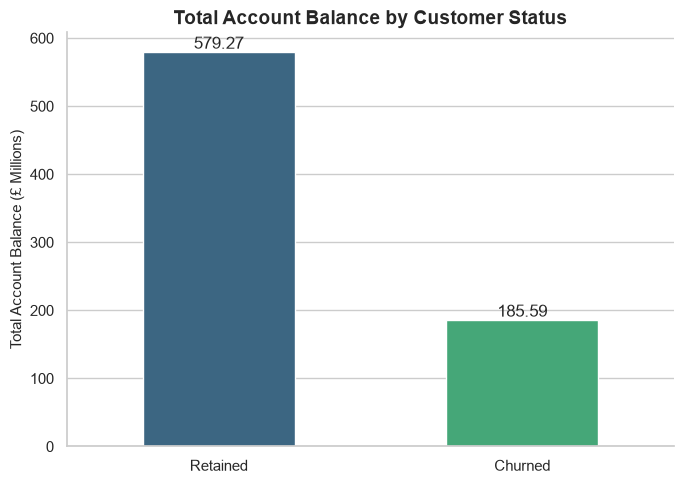

In [41]:
balance_comparison = pd.DataFrame({
    "Customer Status": ["Retained", "Churned"],
    "Total Balance (£ Millions)": [
        df[df["Exited"] == 0]["Balance"].sum() / 1_000_000,
        df[df["Exited"] == 1]["Balance"].sum() / 1_000_000
    ]
})

ax = sns.barplot(
    data=balance_comparison,
    x="Customer Status",
    y="Total Balance (£ Millions)",
    palette="viridis",
    width=0.5
)

plt.title("Total Account Balance by Customer Status")
plt.xlabel("")
plt.ylabel("Total Account Balance (£ Millions)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Churned customers collectively held approximately **£185.59 million**, representing **24.26% of the bank's total deposits**.
- Retained customers account for approximately **£579.27 million**, or **75.74% of the total deposits**.
- Although only **20.37% of customers** churned, they were associated with **24.26% of the bank's total deposits**, indicating that churn disproportionately affects customers with higher account balances.
- The average account balance of churned customers (**£91,108.54**) is significantly higher than that of retained customers (**£72,745.30**), further reinforcing that high-value customers are more likely to churn.

### Business Insight

Customer churn represents a significant financial risk, with nearly **one-quarter of the bank's total deposits** associated with customers who left the bank. These findings highlight the importance of prioritizing retention strategies for high-value customers through personalized financial products, proactive relationship management, and loyalty programs. Reducing churn among these customers can have a substantial positive impact on the bank's financial stability and long-term profitability.